In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

/home/student/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
I0000 00:00:1788772866.593295    7779 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788772866.635868    7779 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788772871.457267    7779 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VN

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (60000, 28, 28)
Testing data: (10000, 28, 28)


In [3]:
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0

print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [4]:
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train,
    train_size=10000,
    random_state=42,
    stratify=y_train
)

print(X_train_small.shape)

(10000, 784)


In [5]:
linear_svm = SVC(kernel='linear')

linear_svm.fit(X_train_small, y_train_small)

y_pred_linear = linear_svm.predict(X_test)

linear_accuracy = accuracy_score(y_test, y_pred_linear)

print("Linear Kernel Accuracy:", linear_accuracy)

Linear Kernel Accuracy: 0.8248


In [6]:
poly_svm = SVC(kernel='poly', degree=3)

poly_svm.fit(X_train_small, y_train_small)

y_pred_poly = poly_svm.predict(X_test)

poly_accuracy = accuracy_score(y_test, y_pred_poly)

print("Polynomial Kernel Accuracy:", poly_accuracy)

Polynomial Kernel Accuracy: 0.818


In [7]:
rbf_svm = SVC(kernel='rbf')

rbf_svm.fit(X_train_small, y_train_small)

y_pred_rbf = rbf_svm.predict(X_test)

rbf_accuracy = accuracy_score(y_test, y_pred_rbf)

print("RBF Kernel Accuracy:", rbf_accuracy)

RBF Kernel Accuracy: 0.8534


In [8]:
print("----- SVM Kernel Comparison -----")
print("Linear Kernel     :", linear_accuracy)
print("Polynomial Kernel :", poly_accuracy)
print("RBF Kernel        :", rbf_accuracy)

----- SVM Kernel Comparison -----
Linear Kernel     : 0.8248
Polynomial Kernel : 0.818
RBF Kernel        : 0.8534


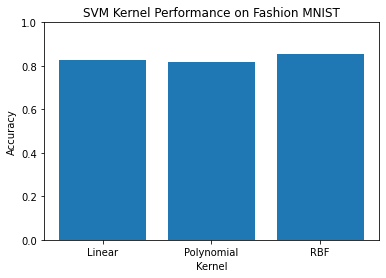

In [9]:
kernels = ['Linear', 'Polynomial', 'RBF']
accuracies = [linear_accuracy, poly_accuracy, rbf_accuracy]

plt.bar(kernels, accuracies)
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.title("SVM Kernel Performance on Fashion MNIST")
plt.ylim(0, 1)
plt.show()

In [10]:
print(classification_report(y_test, y_pred_rbf))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1000
           1       0.99      0.95      0.97      1000
           2       0.76      0.78      0.77      1000
           3       0.82      0.89      0.85      1000
           4       0.76      0.78      0.77      1000
           5       0.94      0.93      0.93      1000
           6       0.66      0.59      0.62      1000
           7       0.90      0.92      0.91      1000
           8       0.95      0.96      0.96      1000
           9       0.93      0.93      0.93      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

